# TensorBoard模型训练可视化

## 【章节目标】
- 知道tensorboard可视化的流程
- 掌握tensorboard相关api的使用
- 熟练使用tensorboard配合tensorflow进行模型训练可视化
- 熟练使用tensorboard配合pytorch进行模型训练可视化

## 【章节内容】

### TensorBoard可视化流程

在我们完成深度学习项目工程中，很多时候我们自己构建模型结构，或者在学习深度学习算法的时候，由于算法结构过于复杂，很难充分理解模型结构层次

你是否想看到自己的模型训练指标与参数的变化情况？

TensorBoard是tensorflow生态中配套的一款神奇的可视化辅助工具，它能够很好的和tensorflow进行配合，对模型、参数、指标进行多种可视化，此外，pytorch1.1开始已经官方支持tensorboard，意味着tensorboard可以直接在pytorch中使用了，不需要再安装TensorboardX。

**TensorBoard可视化流程**

- 安装TensorBoard
- 创建监听目录
- 新建summary实例
- 将数据存入summary实例
- 启动监听并可视化

#### 1）安装TensorBoard
最新的TensorFLow是默认安装了tensorboard，如果你不确定，可以使用以下命令，检查一下是否安装：

In [ ]:
!pip list

#### 2）创建监听目录
首先你需要确定一个存放数据的文件夹，这个文件夹用来存储要监听的数据（比如loss、acc等）。网络在训练过程中，CPU会不断将要监听的数据存入该文件夹所在磁盘位置，然后Web端会实时监听该文件夹内的数据，通过渲染之后，在网页UI上显示出来，方面开发者实时查看网络训练的情况。具体逻辑图如下所示：

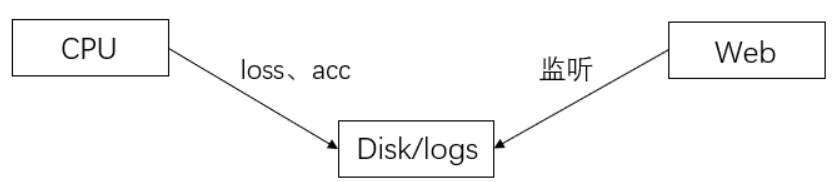

#### 3）新建summary实例
首先，我们需要新建一个 summary 实例，可使用 tf.summary.create_file_writer(file_path) 来创建

In [2]:
import tensorflow as tf
from datetime import datetime
# 读取当前时间，作为存放数据的文件名
current_time = datetime.now().strftime("%Y%m%d-%H%M%S")
# log_dir 是最终监听的文件路径
log_dir = 'log/' + current_time
# 创建writer
summary_writer = tf.summary.create_file_writer(log_dir)

2026-04-07 12:22:46.925021: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-04-07 12:22:46.925250: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-04-07 12:22:46.945146: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-04-07 12:22:50.469424: W tensorflow/core/common_runtime/gpu/gpu_bfc_allocator.cc:47] Overriding orig_value setting because the TF_FORCE_GPU_ALLOW_GROWTH environment variable is set. Original config value was 0.


#### 4）将数据存入summary实例
创建好 summary 实例后，我们将可以将要监听的数据存入该summary实例中。

**虚构一组数据并写入**

In [3]:
import numpy as np
for step, loss in zip(range(1, 1000), np.random.rand(1000)):
    with summary_writer.as_default():
        tf.summary.scalar('train-loss', float(loss), step = step)

以上代码运行后可在当前目录下生成log目录，存储训练过程需要监听的数据

#### 5）启动监听并可视化
进入到 log 所在目录，在终端执行执行以下命令，启动 Tensorboard 后台服务

In [ ]:
tensorboard --logdir=log

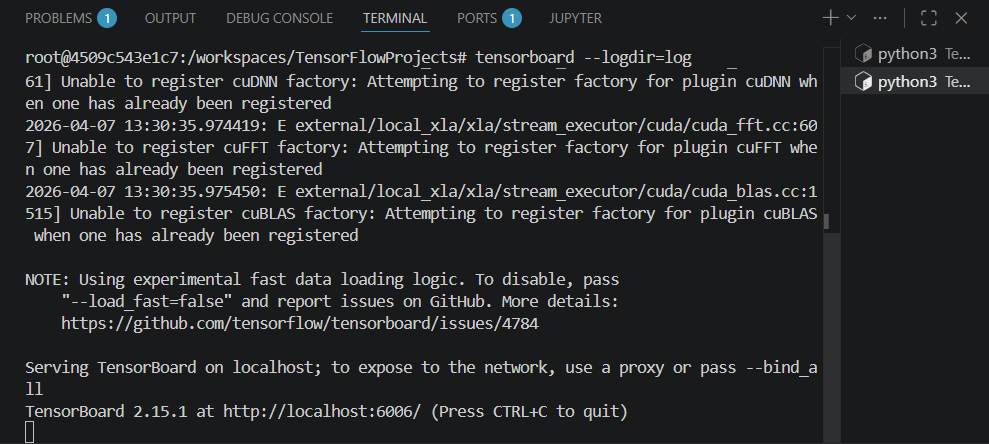

注意：目录和路径要正确，我这里是在docker中

打开浏览器，输入你的网络端口，就可以查看历史监听数据，默认每隔30刷新一次。

### Keras中使用tensorboard
#### 1）Keras训练中使用TensorBoard
Keras在回调函数中内置了TensorBoard函数：

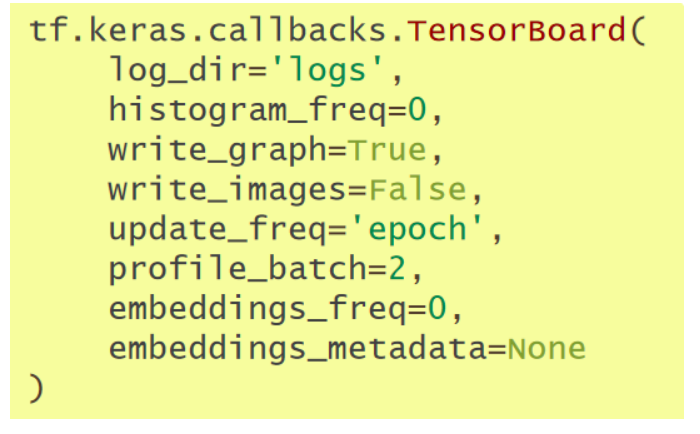

各参数含义如下：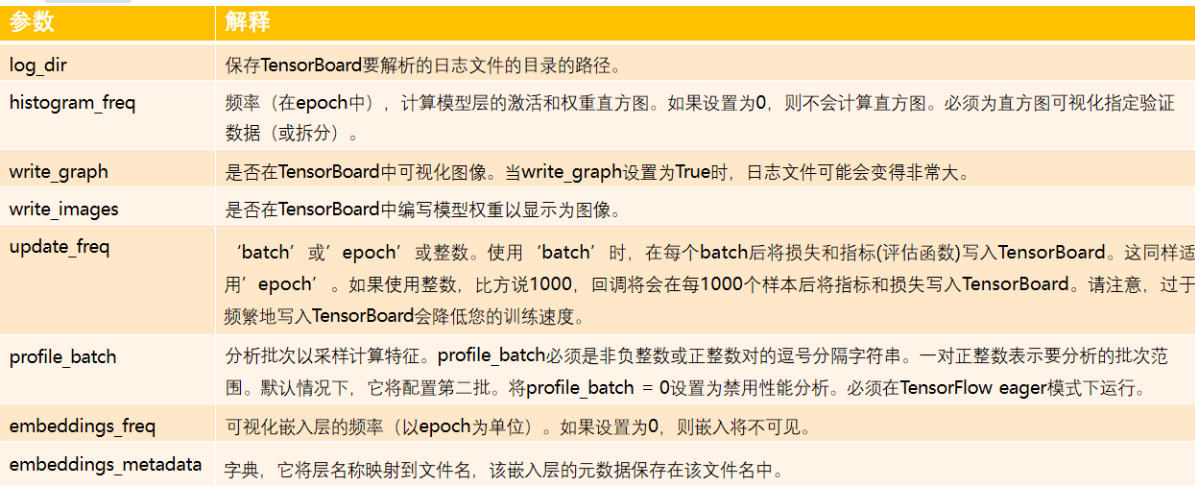

#### 2）Keras训练中使用TensorBoard案例
我们以mnist手写数字识别模型训练为例：

**构建数据和模型**

In [4]:
from tensorflow.keras import layers
#构建数据和模型
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.mnist.load_data()
X_train=X_train.astype('float32')
X_test=X_test.astype('float32')
X_train/=255
X_test/=255
X_train = X_train.reshape(X_train.shape[0], 28, 28, 1).astype('float32')
X_test = X_test.reshape(X_test.shape[0], 28, 28, 1).astype('float32')
y_train = tf.keras.utils.to_categorical(y_train, 10)
y_test = tf.keras.utils.to_categorical(y_test, 10)
#构建模型
model = tf.keras.Sequential()
model.add(layers.Convolution2D(32, 3, 3, input_shape=(28, 28, 1)))
model.add(layers.Activation('relu'))
model.add(layers.Dropout(0.25))
model.add(layers.Convolution2D(32, 3, 3))
model.add(layers.Activation('relu'))
model.add(layers.Convolution2D(32, 3, 3))
model.add(layers.Activation('relu'))
model.add(layers.Dropout(0.25))
model.add(layers.Flatten())
model.add(layers.Dense(128))
model.add(layers.Dense(128))
model.add(layers.Activation('relu'))
model.add(layers.Dense(10))
model.add(layers.Activation('softmax'))
model.compile(loss='categorical_crossentropy',optimizer='adam',metrics=['accuracy'])

In [5]:
log_dir = "log/keras_mnist" + datetime.now().strftime("%Y%m%d-%H%M%S")
# 创建回调
tensorboard_callback = tf.keras.callbacks.TensorBoard(log_dir = log_dir, histogram_freq = 1)
# 使用回调进行训练
model.fit(x = X_train, y = y_train, epochs = 30,
          validation_data = (X_test, y_test),
          callbacks = [tensorboard_callback])

Epoch 1/30


2026-04-07 14:23:29.116694: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:961] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape insequential/dropout/dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer
I0000 00:00:1775571810.619789   17466 device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


1875/1875 [==============================] - 17s 7ms/step - loss: 0.4230 - accuracy: 0.8658 - val_loss: 0.1431 - val_accuracy: 0.9529
Epoch 2/30
1875/1875 [==============================] - 12s 7ms/step - loss: 0.2136 - accuracy: 0.9347 - val_loss: 0.1015 - val_accuracy: 0.9683
Epoch 3/30
1875/1875 [==============================] - 13s 7ms/step - loss: 0.1755 - accuracy: 0.9460 - val_loss: 0.0954 - val_accuracy: 0.9712
Epoch 4/30
1875/1875 [==============================] - 13s 7ms/step - loss: 0.1572 - accuracy: 0.9525 - val_loss: 0.0871 - val_accuracy: 0.9729
Epoch 5/30
1875/1875 [==============================] - 12s 7ms/step - loss: 0.1469 - accuracy: 0.9547 - val_loss: 0.0774 - val_accuracy: 0.9750
Epoch 6/30
1875/1875 [==============================] - 15s 8ms/step - loss: 0.1341 - accuracy: 0.9589 - val_loss: 0.0799 - val_accuracy: 0.9755
Epoch 7/30
1875/1875 [==============================] - 16s 8ms/step - loss: 0.1280 - accuracy: 0.9600 - val_loss: 0.0774 - val_accuracy: 0.9

监听：

- 终端方式, 跟上面一样
- notebook方式，需要加载TensorBoard扩展程序

notebook方式示例：

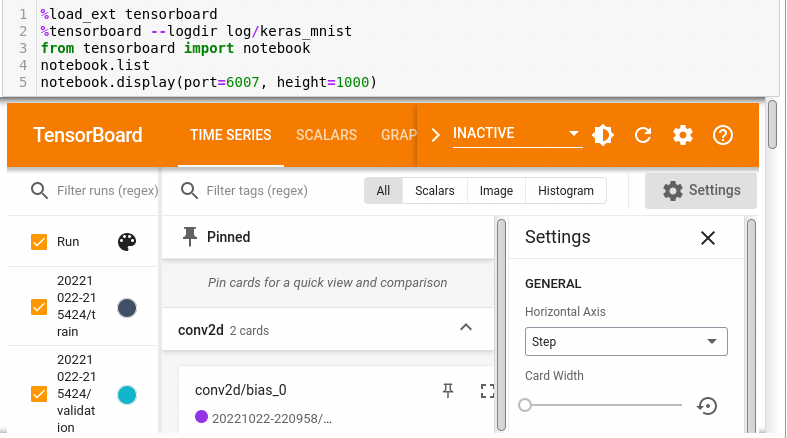

#### 3）Tensorboard界面解释

- Scalars : 显示了如何将loss与每个时间段改变。还可以使用它来跟踪训练速度，学习率和其他标量值。

- Graphs：进行可视化模型。在这种情况下，将显示层的Keras图，这可以帮助你确保模型正确构建。

- Distributions 和 Histograms ：显示张量随时间的分布。这对于可视化权重和偏差并验证它们是否以预期的方式变化很有

### 自定义训练中使用
#### 1）创建summary writer实例

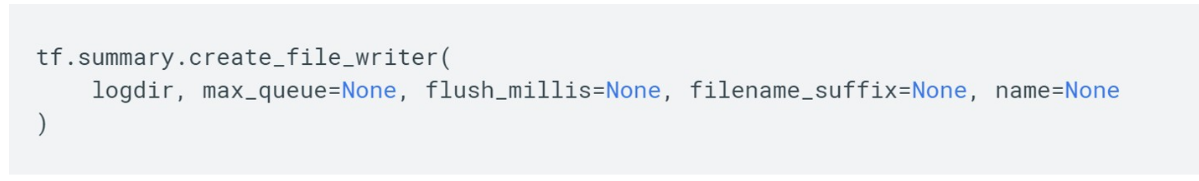

各参数含义：

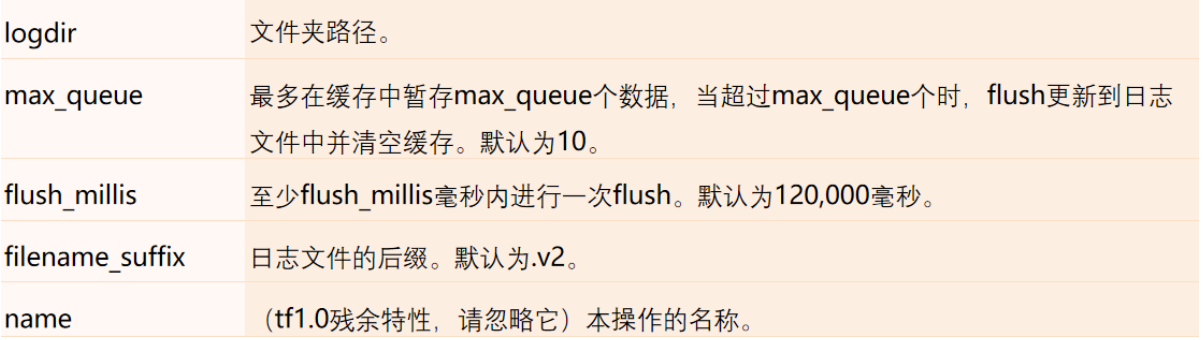

#### 2）数据写入
- 写入图像数据：用来监听样本图像和卷积特征图等图像数据，形状为[k, h, w, c]的Tensor。
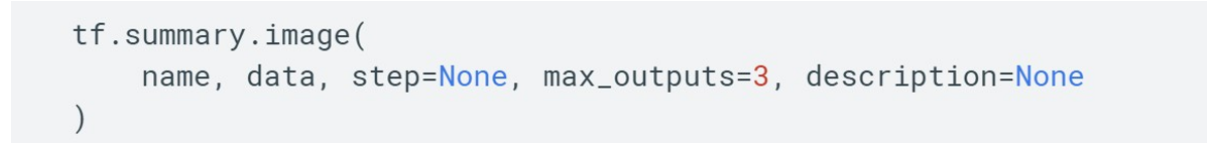

- 写入标量数据：用来监听损失、评估指标、学习率等标量数据。在tensorboard中将生成折线图
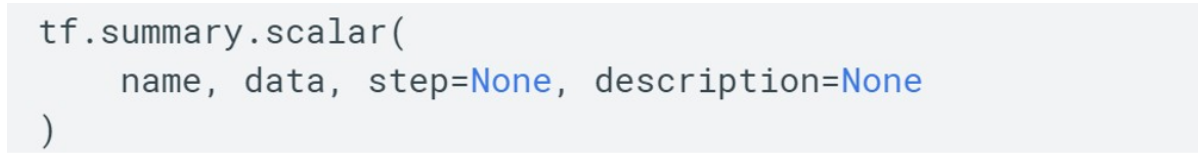

- 写入文本数据：用来监听文本数据，tf.string类型的Tensor。
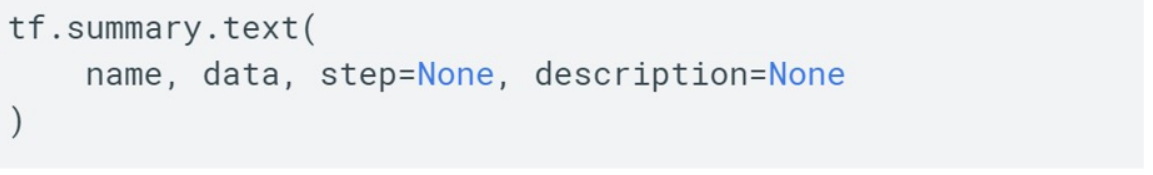

- 统计直方图：用来监听绘制参数分布
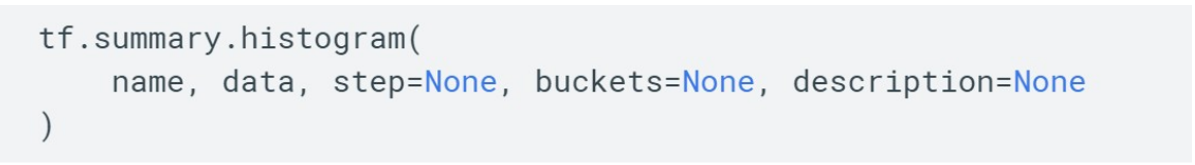

- 写入音频数据：用来监听音频数据，形状为[k, t, c]的Tensor。
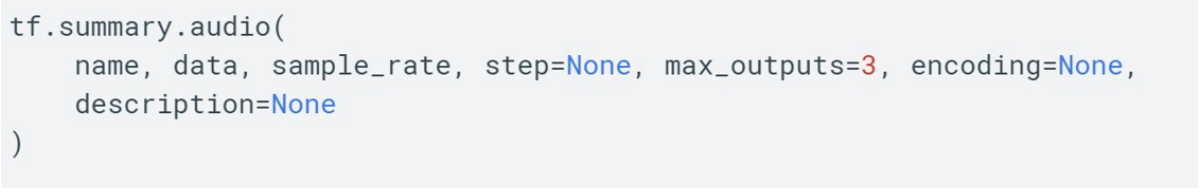

#### 3）查看Graph和Profile信息
- tf.summary.trace_export()：停止trace，并将之前trace记录到的信息写入profiler日志文件。
- tf.summary.trace_off()：停止trace，并舍弃之前trace记录。
- tf.summary.trace_on()：开始trace以记录计算图和分析信息。此时 TensorFlow 会将训练时的大量信息（如计算图的结构，每个操作所耗费的时间等）记录下来

在 TensorFlow 2.3 及后续版本中，需要使用:pip install -U tensorboard-plugin-profile安装独立的 TensorBoard Profile 插件以使用 Profile 功能。  
**这里我指定版本用pip install tensorboard-plugin-profile "protobuf<4.24"**

In [9]:
!pip install tensorboard-plugin-profile "protobuf<4.24"

  Using cached google_auth-2.49.1-py3-none-any.whl.metadata (6.2 kB)
  Using cached cryptography-46.0.6-cp311-abi3-manylinux_2_34_x86_64.whl.metadata (5.7 kB)
INFO: pip is looking at multiple versions of google-cloud-storage-control to determine which version is compatible with other requirements. This could take a while.
INFO: pip is looking at multiple versions of google-api-core to determine which version is compatible with other requirements. This could take a while.
INFO: pip is looking at multiple versions of google-api-core[grpc] to determine which version is compatible with other requirements. This could take a while.
INFO: pip is looking at multiple versions of grpc-google-iam-v1 to determine which version is compatible with other requirements. This could take a while.
INFO: pip is looking at multiple versions of proto-plus to determine which version is compatible with other requirements. This could take a while.
INFO: pip is looking at multiple versions of googleapis-common-p

#### 4）自定以训练使用tensorboard案例
##### 1.构建数据和模型

In [1]:
import tensorflow as tf
from tensorflow.keras import layers
from datetime import datetime
#构建数据和模型
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.mnist.load_data()
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0
X_train = X_train.reshape(X_train.shape[0], 28, 28, 1)
X_test = X_test.reshape(X_test.shape[0], 28, 28, 1)
y_train = tf.keras.utils.to_categorical(y_train, 10)
y_test = tf.keras.utils.to_categorical(y_test, 10)
#构建数据集
train_db = tf.data.Dataset.from_tensor_slices((X_train, y_train)).shuffle(10000).batch(128)
val_db = tf.data.Dataset.from_tensor_slices((X_test, y_test)).shuffle(5000).batch(256)
#构建模型
model = tf.keras.Sequential()
model.add(layers.Conv2D(32, (3, 3), input_shape=(28, 28, 1), name='conv2d_1'))
model.add(layers.Activation('relu'))
model.add(layers.Dropout(0.25))
model.add(layers.Conv2D(32, (3, 3), name='conv2d_2'))
model.add(layers.Activation('relu'))
model.add(layers.Conv2D(32, (3, 3), name='conv2d_3'))
model.add(layers.Activation('relu'))
model.add(layers.Dropout(0.25))
model.add(layers.Flatten())
model.add(layers.Dense(128, name='dense_1'))
model.add(layers.Dense(128, name='dense_2'))
model.add(layers.Activation('relu'))
model.add(layers.Dense(10, name='dense_3'))
model.add(layers.Activation('softmax'))

2026-04-07 16:43:47.482846: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-04-07 16:43:47.482912: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-04-07 16:43:47.483890: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-04-07 16:43:50.537676: W tensorflow/core/common_runtime/gpu/gpu_bfc_allocator.cc:47] Overriding orig_value setting because the TF_FORCE_GPU_ALLOW_GROWTH environment variable is set. Original config value was 0.


##### 2.创建summary writer实例

In [2]:
log_dir = "log/tape_mnist/" + datetime.now().strftime("%Y%m%d-%H%M%S")
#创建summary writer实例
summary_writer = tf.summary.create_file_writer(log_dir)
#开启Trace，开始记录图结构和profile信息
## tf.summary.trace_on(graph = True, profiler = True) ## fix: 不能在这里开启，第一个epoch记录一下结构就行了，不然内存要炸

##### 3.定义损失、优化器和评估函数

In [3]:
#1.定义损失函数    
loss_func=tf.keras.losses.CategoricalCrossentropy()
# 2. 先创建指数衰减学习率
exponential_decay = tf.keras.optimizers.schedules.ExponentialDecay(
    initial_learning_rate=1e-4, 
    decay_steps=100, 
    decay_rate=0.99)
# 3. 送入优化器
optimizer = tf.keras.optimizers.Adam(exponential_decay)
#4.定义评估函数
acc=tf.keras.metrics.CategoricalAccuracy()

##### 4.开启训练并监听数据

In [4]:
model.get_config()['layers']

[{'module': 'keras.layers',
  'class_name': 'InputLayer',
  'config': {'batch_input_shape': (None, 28, 28, 1),
   'dtype': 'float32',
   'sparse': False,
   'ragged': False,
   'name': 'conv2d_1_input'},
  'registered_name': None},
 {'module': 'keras.layers',
  'class_name': 'Conv2D',
  'config': {'name': 'conv2d_1',
   'trainable': True,
   'dtype': 'float32',
   'batch_input_shape': (None, 28, 28, 1),
   'filters': 32,
   'kernel_size': (3, 3),
   'strides': (1, 1),
   'padding': 'valid',
   'data_format': 'channels_last',
   'dilation_rate': (1, 1),
   'groups': 1,
   'activation': 'linear',
   'use_bias': True,
   'kernel_initializer': {'module': 'keras.initializers',
    'class_name': 'GlorotUniform',
    'config': {'seed': None},
    'registered_name': None},
   'bias_initializer': {'module': 'keras.initializers',
    'class_name': 'Zeros',
    'config': {},
    'registered_name': None},
   'kernel_regularizer': None,
   'bias_regularizer': None,
   'activity_regularizer': None,


In [5]:
layer_names = [item['config']['name'] for item in model.get_config()['layers']
               if item['class_name'] in ['Conv2D', 'Dense']]
layer_names

['conv2d_1', 'conv2d_2', 'conv2d_3', 'dense_1', 'dense_2', 'dense_3']

In [6]:
# 定义监听参数的函数
def log_w_b(step):
    with summary_writer.as_default():
        for layer_name in layer_names: # 遍历每一层的名字
            layer = model.get_layer(layer_name) # 获取当前层
            w, b = layer.weights # 获取当前层的参数
            tf.summary.histogram(w.name, w, step=step)
            tf.summary.histogram(b.name, b, step=step)

注意：下面训练完，由于在 TF 2.x 的原生动态图模式下开启 tf.summary.trace_on() 时，它并不会去解析你的 model 是怎么构建的。图只会记录基础运算而不是网络结构。

In [7]:
# 开启训练
epochs = 30
for  epoch in range(1,epochs+1):
    print('-'*10+f"epoch{epoch}"+'-'*10)
    #遍历数据集进行训练
    train_loss=0.0
    acc.reset_states()
    for step, (x_batch_train, y_batch_train) in enumerate(train_db):
        # 开一个gradient tape, 计算梯度
        if epoch == 1 and step == 0:
            tf.summary.trace_on(graph=True, profiler=True)

        with tf.GradientTape() as tape:
            predictions = model(x_batch_train)#计算输出值
            loss = loss_func(y_batch_train, predictions)#计算损失值

        gradients = tape.gradient(loss, model.trainable_variables)#计算梯度值
        optimizer.apply_gradients(zip(gradients, model.trainable_variables))#优化更新参数
        train_loss += loss / len(train_db)#累计平均损失，这里使用python原生方法，Keras 的原生写法参考↓
        # # 在循环外定义
        # train_loss_metric = tf.keras.metrics.Mean('train_loss')

        # # 在每次 step 里更新
        # train_loss_metric.update_state(loss)

        # # 在每个 epoch 结束时拿结果并重置
        # final_loss = train_loss_metric.result().numpy()
        # train_loss_metric.reset_states()
        acc.update_state(y_batch_train, predictions)
#       global_step=optimizer.iterations.numpy()
#       if global_step % 100 == 0: # 这里batch不大，直接结束后在监听即可，不用按step分
        if epoch == 1 and step == 0:
            with summary_writer.as_default():
                tf.summary.trace_export(name="model_trace", step=0, profiler_outdir=log_dir)

    log_w_b(epoch) # 监听各层的参数直方图
    acc_value = acc.result().numpy()

    with summary_writer.as_default():
        tf.summary.scalar('train_loss', train_loss, step = epoch) # 监听损失值
        tf.summary.scalar('train_acc', acc_value, step = epoch) # 监听准确率
        tf.summary.scalar('lr', exponential_decay(optimizer.iterations).numpy(), step = epoch) # 监听学习率 如何提取当前学习率
    print('epoch %s---Training loss : %s---Training acc : %s ' % (epoch, 
                                                                  float(train_loss),
                                                                  acc_value))
    
    # 遍历验证集进行验证
    val_loss = 0
    acc.reset_states()
    for x_batch_val, y_batch_val in val_db: # 不需要求梯度
        predictions = model(x_batch_val) # 计算输出值
        loss = loss_func(y_batch_val, predictions) # 计算损失值
        val_loss += loss / len(val_db) # 累计平均损失
        acc.update_state(y_batch_val, predictions)

    with summary_writer.as_default():
        tf.summary.scalar('val_loss', val_loss, step = epoch) # 监听损失值
        tf.summary.scalar('val_acc', acc.result().numpy(), step = epoch) # 监听准确率
    print('epoch %s---val loss : %s---val acc : %s ' % (epoch, 
                                                        float(val_loss),
                                                        acc.result().numpy()))

----------epoch1----------
Instructions for updating:
use `tf.profiler.experimental.start` instead.


I0000 00:00:1775580866.109338   16395 device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


Instructions for updating:
use `tf.profiler.experimental.stop` instead.
Instructions for updating:
`tf.python.eager.profiler` has deprecated, use `tf.profiler` instead.
Instructions for updating:
`tf.python.eager.profiler` has deprecated, use `tf.profiler` instead.
epoch 1---Training loss : 0.3465105891227722---Training acc : 0.9098833 
epoch 1---val loss : 0.09961021691560745---val acc : 0.971 
----------epoch2----------
epoch 2---Training loss : 0.09244828671216965---Training acc : 0.9731333 
epoch 2---val loss : 0.06302482634782791---val acc : 0.9791 
----------epoch3----------
epoch 3---Training loss : 0.0659671351313591---Training acc : 0.98043334 
epoch 3---val loss : 0.051593609154224396---val acc : 0.9825 
----------epoch4----------
epoch 4---Training loss : 0.050969842821359634---Training acc : 0.98471665 
epoch 4---val loss : 0.04343477264046669---val acc : 0.9847 
----------epoch5----------
epoch 5---Training loss : 0.04184434190392494---Training acc : 0.98791665 
epoch 5---

### pytorch中使用tensorboard
#### 1）TensorBoard可视化流程
- 首先在pytorch项目中指定一个目录创建一个torch.utils.tensorboard.SummaryWriter日志写入器。
- 然后根据需要的可视化信息，利用写入器将相关的模型结构、指标，图像写入到指定目录下
- 关闭写入器
- 最后通过终端输入命令，在命令中传入目录参数，启动TensorBoard。

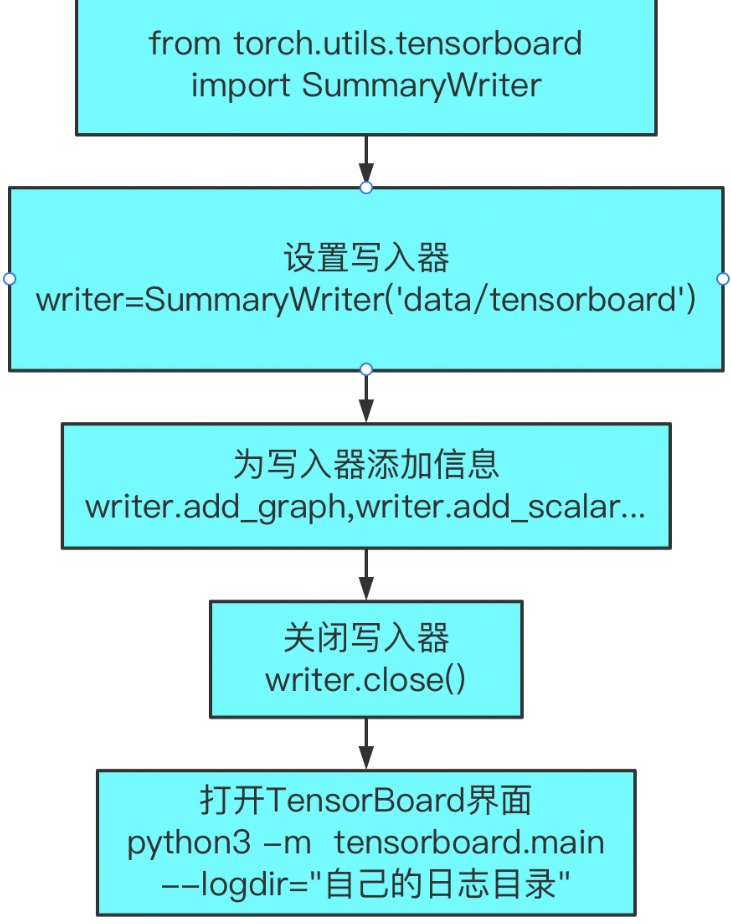

#### 2）可视化方法
- 可视化模型结构 writer.add_graphh(model, input_to_model=None, verbose=False)
    - model：模型，必须是 nn.Module
    - input_to_model：输入给模型的数据
    - verbose：是否打印计算图结构信息

- 可视化指标变化 writer.add_scalar(tag, scalar_value, global_step=None)
    - tag：图像的标签名，图的唯一标识
    - scalar_value：要记录的标量
    - global_step：x轴

- 可视化参数分布 writer.add_histogramm(tag, values, global_step=None, bins='tensorflow')
    - tag：图像的标签名，图的唯一标识
    - values：要统计的参数
    - global_step：y轴
    - bins：取直方图的bins

- 可视化原始图像 writer.add_image(tag, img_tensor, global_step=None, walltime=None, dataformats='CHW')
    - tag：图像的标签名，图的唯一标识
    - img_tensor：图像数据，注意尺度
    - global_step：x轴
    - dataformats：数据形式，CHW，HWC，HW

- 制作网格图像 torchvision.utils.make_grid(tensor, nrow=8, padding=2, normalize=False, range=None, scale_each=False, pad_value=0)
    - tensor：图像数据, BCH*W形式
    - nrow：行数（列数自动计算）
    - padding：图像间距（像素单位）
    - normalize：是否将像素值标准化
    - range：标准化范围
    - scale_each：是否单张图维度标准化
    - pad_value：padding的像素值

- 可视化人工绘图 writer.add_figure()

#### 3）pytorch可视化案例
我们还是以mnist手写数字识别为例演示pytorch模型可视化

**构建数据集和模型**

In [3]:
import torchvision
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torch
from torch.utils.tensorboard import SummaryWriter # 引入工具包

batch_size_train = 64
batch_size_test=256
random_seed = 1
torch.manual_seed(random_seed)
train_loader = torch.utils.data.DataLoader(
torchvision.datasets.MNIST('./Dataset/', train=True, download=True,
                             transform=torchvision.transforms.Compose([
                               torchvision.transforms.ToTensor(),
                               torchvision.transforms.Normalize(
                                 (0.1307,), (0.3081,))
                             ])), batch_size=batch_size_train, shuffle=True)
test_loader = torch.utils.data.DataLoader(
torchvision.datasets.MNIST('./Dataset/', train=False, download=True,
                             transform=torchvision.transforms.Compose([
                               torchvision.transforms.ToTensor(),
                               torchvision.transforms.Normalize(
                                 (0.1307,), (0.3081,))
                             ])), batch_size=batch_size_test, shuffle=True)

#搭建模型
class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        self.conv1 = nn.Conv2d(1, 10, kernel_size=5)
        self.conv2 = nn.Conv2d(10, 20, kernel_size=5)
        self.conv2_drop = nn.Dropout2d()
        self.fc1 = nn.Linear(320, 50)
        self.fc2 = nn.Linear(50, 10)
    def forward(self, x):
        x = F.relu(F.max_pool2d(self.conv1(x), 2))
        x = F.relu(F.max_pool2d(self.conv2_drop(self.conv2(x)), 2))
        x = x.view(-1, 320)
        x = F.relu(self.fc1(x))
        x = F.dropout(x, training=self.training)
        x = self.fc2(x)
        return F.log_softmax(x)

100%|██████████| 9.91M/9.91M [00:05<00:00, 1.71MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 135kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.16MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 9.93kB/s]


**创建writer**

In [5]:
writer = SummaryWriter('../Pytorch/log/tensorboard_1') # 创建writer
model = Net()
dummy_input = torch.rand(20, 1, 28, 28) # 假设输入20张1*28*28的图片
writer.add_graph(model, input_to_model = dummy_input) # 写入网络结构

C:\Users\lenovo\AppData\Local\Temp\ipykernel_65076\2228520256.py:43: UserWarning: Implicit dimension choice for log_softmax has been deprecated. Change the call to include dim=X as an argument.
  return F.log_softmax(x)


**监听训练过程**

In [6]:
loss_func = torch.nn.NLLLoss()
optimizer = torch.optim.Adam(model.parameters(), lr = 1e-4)
def train(network, loss_func, optimizer, n_epochs = 10):
    network.train()
    for epoch in range(n_epochs):
        total_loss = 0.0
        for batch_idx, (data, target) in enumerate(train_loader):
            ### 记录一批图片 ###
            if batch_idx == 0:
                img_grid = torchvision.utils.make_grid(data)
                writer.add_image('image_grid', img_grid, epoch)
            optimizer.zero_grad()
            output = network(data)
            loss = loss_func(output, target)
            loss.backward()
            optimizer.step()
            total_loss += loss.item() / len(train_loader)
        ### 记录损失(标量记录) ###
        writer.add_scalar('loss', total_loss, epoch) # 日志中记录loss
        ### 记录参数分布 ###
        for name, param in model.named_parameters():
            writer.add_histogram(name, param.detach().numpy(), epoch) # 对参数进行监听

In [7]:
train(model, loss_func, optimizer, 30)

C:\Users\lenovo\AppData\Local\Temp\ipykernel_65076\2228520256.py:43: UserWarning: Implicit dimension choice for log_softmax has been deprecated. Change the call to include dim=X as an argument.
  return F.log_softmax(x)


In [8]:
### 关闭write ###
writer.close()

**启动tensorboard观察**

前面的方法打开观察即可